# Smoothing, Volume, and Samples

Take a look at the data below. What do you see?

Despite the sparsity and noise, a pattern is visible, and one often wants to infer the underlying smooth function which produced the data. A common misconception is that it is necessary to assume a degree of smoothness in order to avoid overfitting the noise.

This notebook illustrates why that is not the case. It turns out we can jointly infer the function and its smoothness in a sensible way using Bayes' theorem and Gaussian processes. This problem teaches us the importance of parameter volume in high dimensions, explains why the posterior maximum often looks nothing whatsoever like a posterior sample, and demonstrates that uncertainty quantification is valuable even if one does not need uncertainties.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


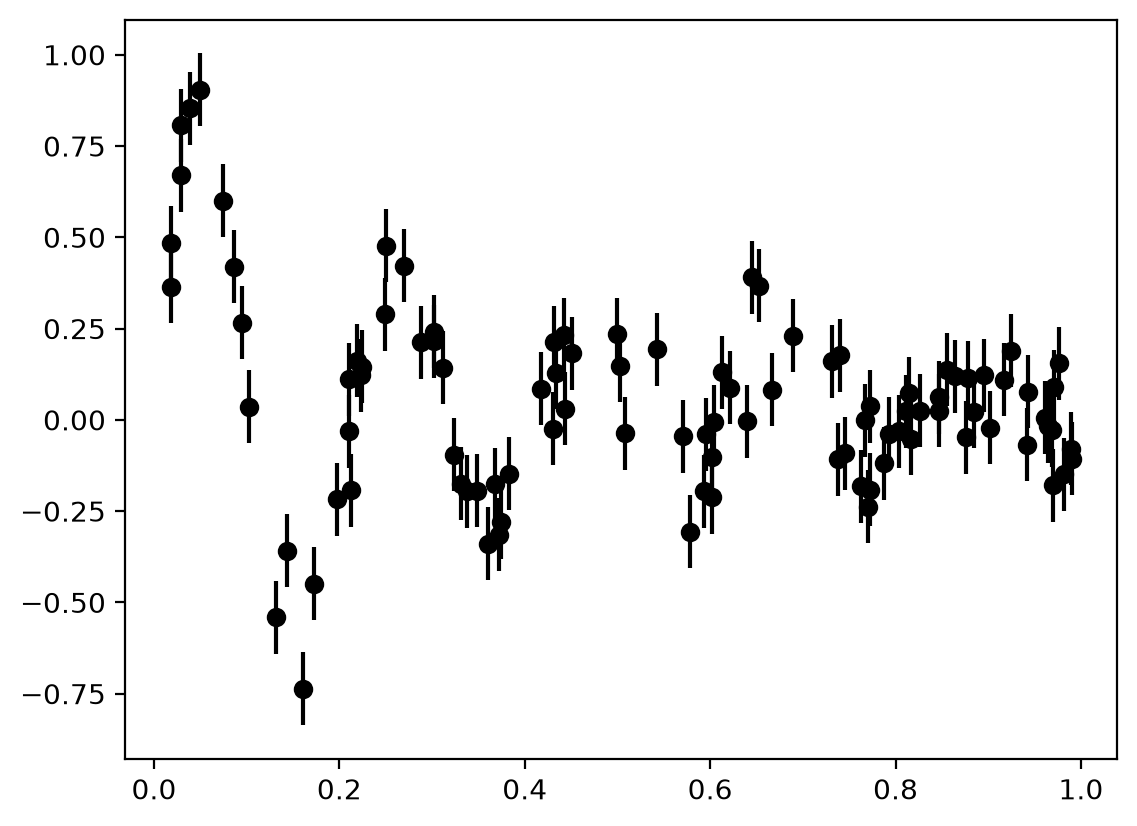

In [2]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
rng = jr.key(123)

# Example data
x = jnp.linspace(0, 1, 100)
y = jnp.sin(30*x) * jnp.exp(-3*x)
k1, k2 = jr.split(jr.key(2))
data_x = jr.uniform(k2, (100,))
data_err = 0.1 * jnp.ones_like(data_x)
data_y = jnp.interp(data_x, x, y) + data_err * jr.normal(k1, data_x.shape)
plt.errorbar(data_x, data_y, yerr=data_err, fmt='o', c='k')
plt.show()

Before diving in, consider a lower-dimensional problem. Suppose we observe a *single* data point, $d=1$, which we think is drawn from a Gaussian distribution with mean $\mu$ and variance $v$. Bayes' theorem says

$$ P(\mu,v|d) = \frac{P(d|\mu,v)\,P(\mu,v)}{P(d)} $$

For the prior let us choose wide Gaussians for $\mu$ and $\log v$, to guarantee positive variance. Since we are only in two dimensions, we can grid the posterior explicitly. Take a moment to reason through the plots below.

As you may have noticed, the posterior maximum (MAP) represents a narrow Gaussian with finely-tuned mean, increasing the likelihood but overfitting the data. Posterior samples, on the other hand, are typically wider Gaussians with a larger range in mean. Any given point in this region has lower probability density, but there is a larger total "volume" of acceptable parameter space, leading more random samples to come from this region! The interplay between volume and density is key to understanding Bayes in high dimensions.

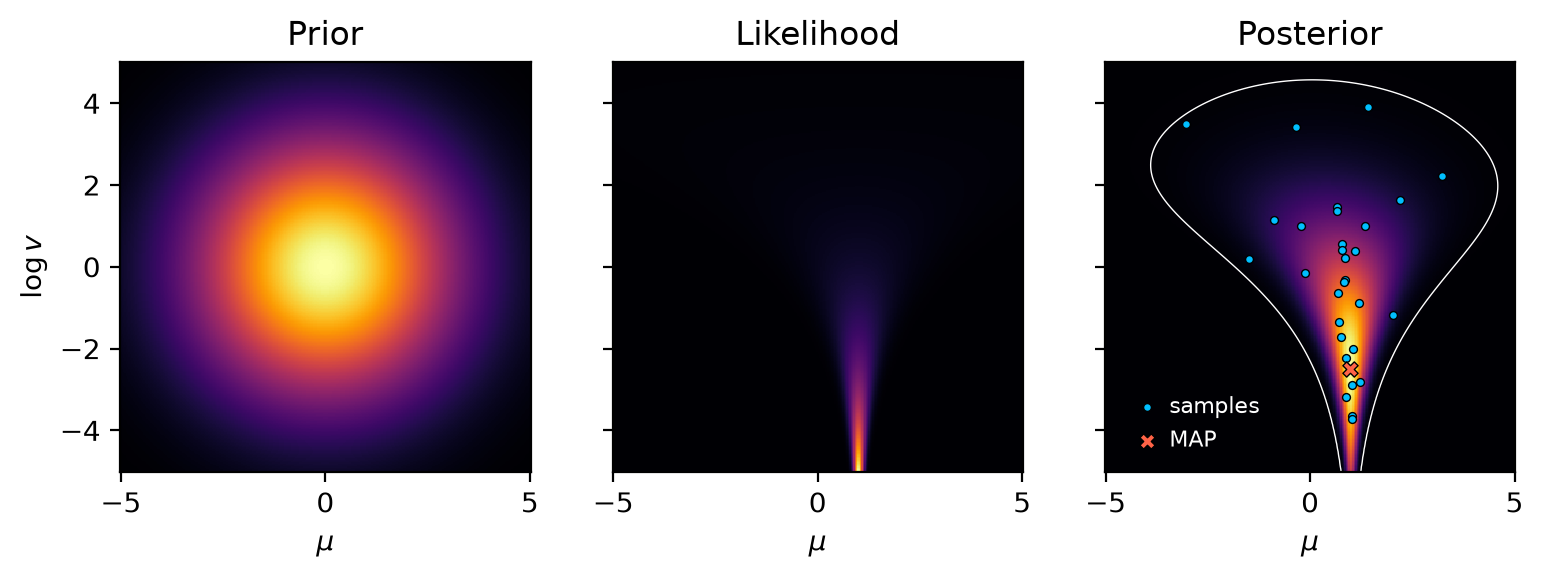

In [3]:
# Data and parameters
d = 1
mu, logvar = jnp.mgrid[-5:5:300j, -5:5:300j]
var = jnp.exp(logvar)

# Bayes theorem
prior = jnp.exp(-1/2 * (mu**2 / 5)) * jnp.exp(-1/2 * (logvar**2 / 5))
likelihood = jnp.exp(-1/2 * ((mu - d)**2 / var)) / jnp.sqrt(2 * jnp.pi * var)
posterior = prior * likelihood

# Posterior samples
samples_idx = jr.choice(jr.key(0), a=posterior.size, p=jnp.ravel(posterior), shape=(30,))
samples_mu, samples_logvar = jnp.ravel(mu)[samples_idx], jnp.ravel(logvar)[samples_idx]

# Posterior maximum (MAP)
map_idx = jnp.argmax(posterior)
map_mu, map_logvar = jnp.ravel(mu)[map_idx], jnp.ravel(logvar)[map_idx]

# Plot!
fig, axes = plt.subplots(ncols=3, figsize=(9,3), sharey=True)
axes[0].pcolormesh(mu, logvar, prior, cmap='inferno')
axes[1].pcolormesh(mu, logvar, likelihood, cmap='inferno')
axes[2].pcolormesh(mu, logvar, posterior, cmap='inferno')
axes[2].scatter(samples_mu, samples_logvar, color='deepskyblue', edgecolor='black', s=8, lw=0.5, label='samples')
axes[2].scatter(map_mu, map_logvar, marker='X', facecolor='tomato', edgecolor='black', s=30, lw=0.5, label='MAP')
axes[2].contour(mu, logvar, posterior, [0.005], colors='white', linewidths=0.5)
for i, ax in enumerate(axes):
    ax.set(box_aspect=1, title=['Prior', 'Likelihood', 'Posterior'][i], xlabel=r'$\mu$', ylabel=r'$\log v$' if i==0 else '')
axes[2].legend(fontsize=8, frameon=False, labelcolor='white', handletextpad=0.0)
plt.show()

To make this result more obvious, we can integrate over $\mu$ to obtain the "marginal" posterior for $\log v$. Due to the volume effect, the joint MAP is quite a bit lower than "most" of the posterior and also the new marginal MAP. One might object that this whole story depends on the parameterization, and that's exactly the point! MAP is coordinate-dependent, whereas the act of sampling from the posterior is the same no matter which parameterization we choose. Sometimes the parameterization is friendly and MAP works fine, but sometimes not. That's what we will see next with Gaussian processes.

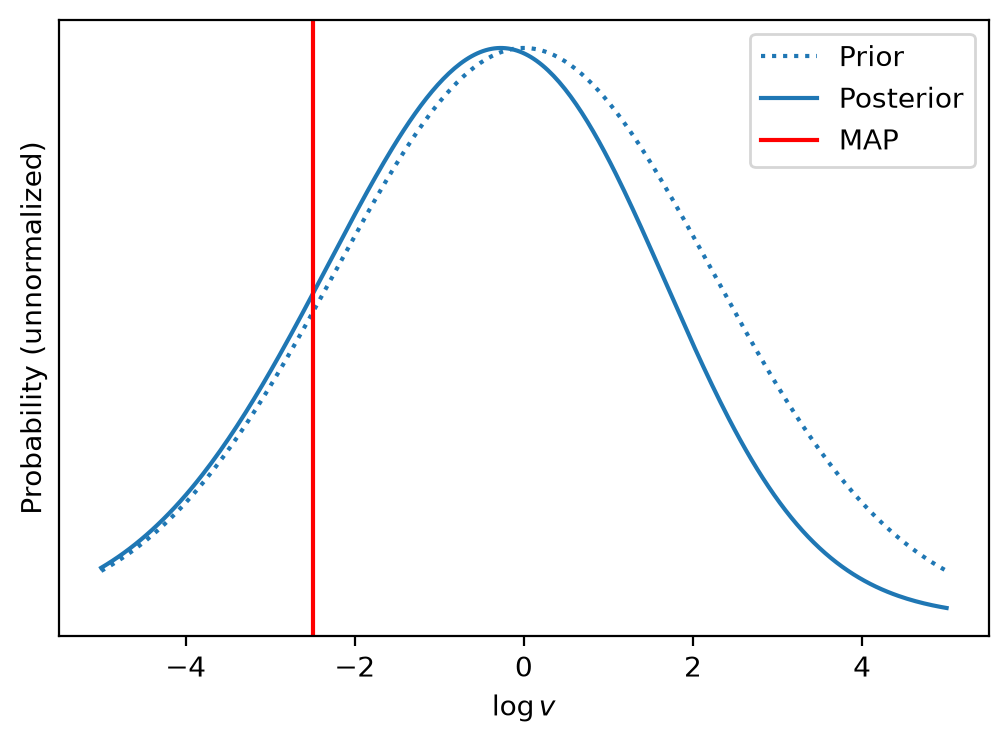

In [4]:
marginal_posterior = jnp.sum(posterior, axis=0)
marginal_prior = jnp.sum(prior, axis=0)

plt.figure(figsize=(6,4))
plt.plot(logvar[0], marginal_prior / jnp.max(marginal_prior), c='C0', ls=':', label='Prior')
plt.plot(logvar[0], marginal_posterior / jnp.max(marginal_posterior), c='C0', label='Posterior')
plt.axvline(map_logvar, color='red', linestyle='-', label='MAP')
plt.gca().set(xlabel=r'$\log v$', ylabel='Probability (unnormalized)', yticks=[])
plt.legend()
plt.show()

A Gaussian process is a "stochastic process (a collection of random variables indexed by time or space), such that every finite collection of those random variables has a multivariate normal distribution" ([Wikipedia](https://en.wikipedia.org/wiki/Gaussian_process)). The key ingredient is the covariance between any two points in space or time. A *stationary* Gaussian process is one where the covariance depends only on some kind of distance between the points, resulting in a field which is (statistically) homogeneous and isotropic.

Gaussian processes are great for representing distributions of smooth functions. For example, take the simple covariance kernel below. By sampling from a mean-zero GP with different values of $s$, we can obtain functions of varying smoothness. Remember, all we are doing here is sampling from one big multivariate Gaussian.

$$ k(r) = \exp\left(-\frac{r^2}{2s^2} \right) $$

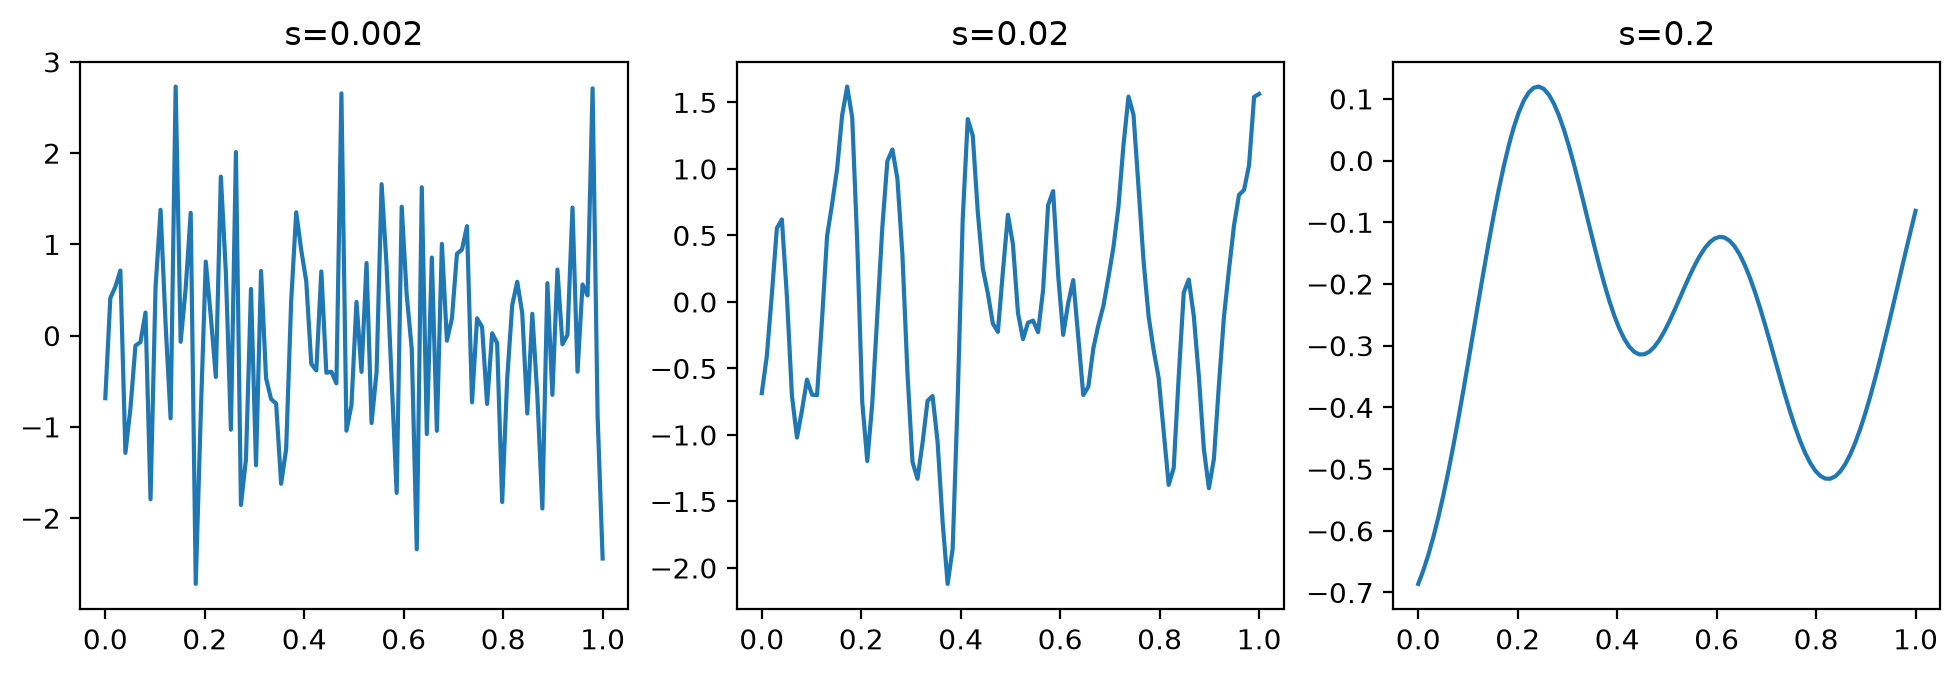

In [5]:
# Forward model
def kernel(logscale):
    r = jnp.abs(x[:, None] - x[None, :])
    K = jnp.exp(-0.5 * (r / jnp.exp(logscale))**2)
    K *= jnp.where(r == 0, 1 + 1e-14, 1)
    return K

def field(logscale, xi):
    K = kernel(logscale)
    L = jnp.linalg.cholesky(K)
    return L @ xi

# Random samples
rng, k1 = jr.split(rng)
xi = jr.normal(k1, (x.shape[0],))

fig, axes = plt.subplots(ncols=3, figsize=(12,4))
for ax, s in zip(axes, [0.002, 0.02, 0.2]):
    f = field(jnp.log(s), xi)
    ax.plot(x, f)
    ax.set(title=f"s={s}", box_aspect=1)
plt.show()

What happens if we jointly infer the smoothing scale $s$ along with the Gaussian process parameters which define the field?

As a technical aside, high-dimensional problems like this can become intractable very quickly. However, in the case of a fixed kernel, the Gaussian prior and Gaussian likelihood make for a Gaussian posterior which can be calculated analytically. We can then afford to build an explicit grid over $s$, the only troublesome nonlinear parameter, and compute things like the marginal posterior, posterior samples, and posterior maximum in standardized coordinates. These are all great introductory exercises so they are left to the reader with the code below as a hint :)

Take a look at the results and see if you can understand them in terms of the intuition from the 2D problem above.

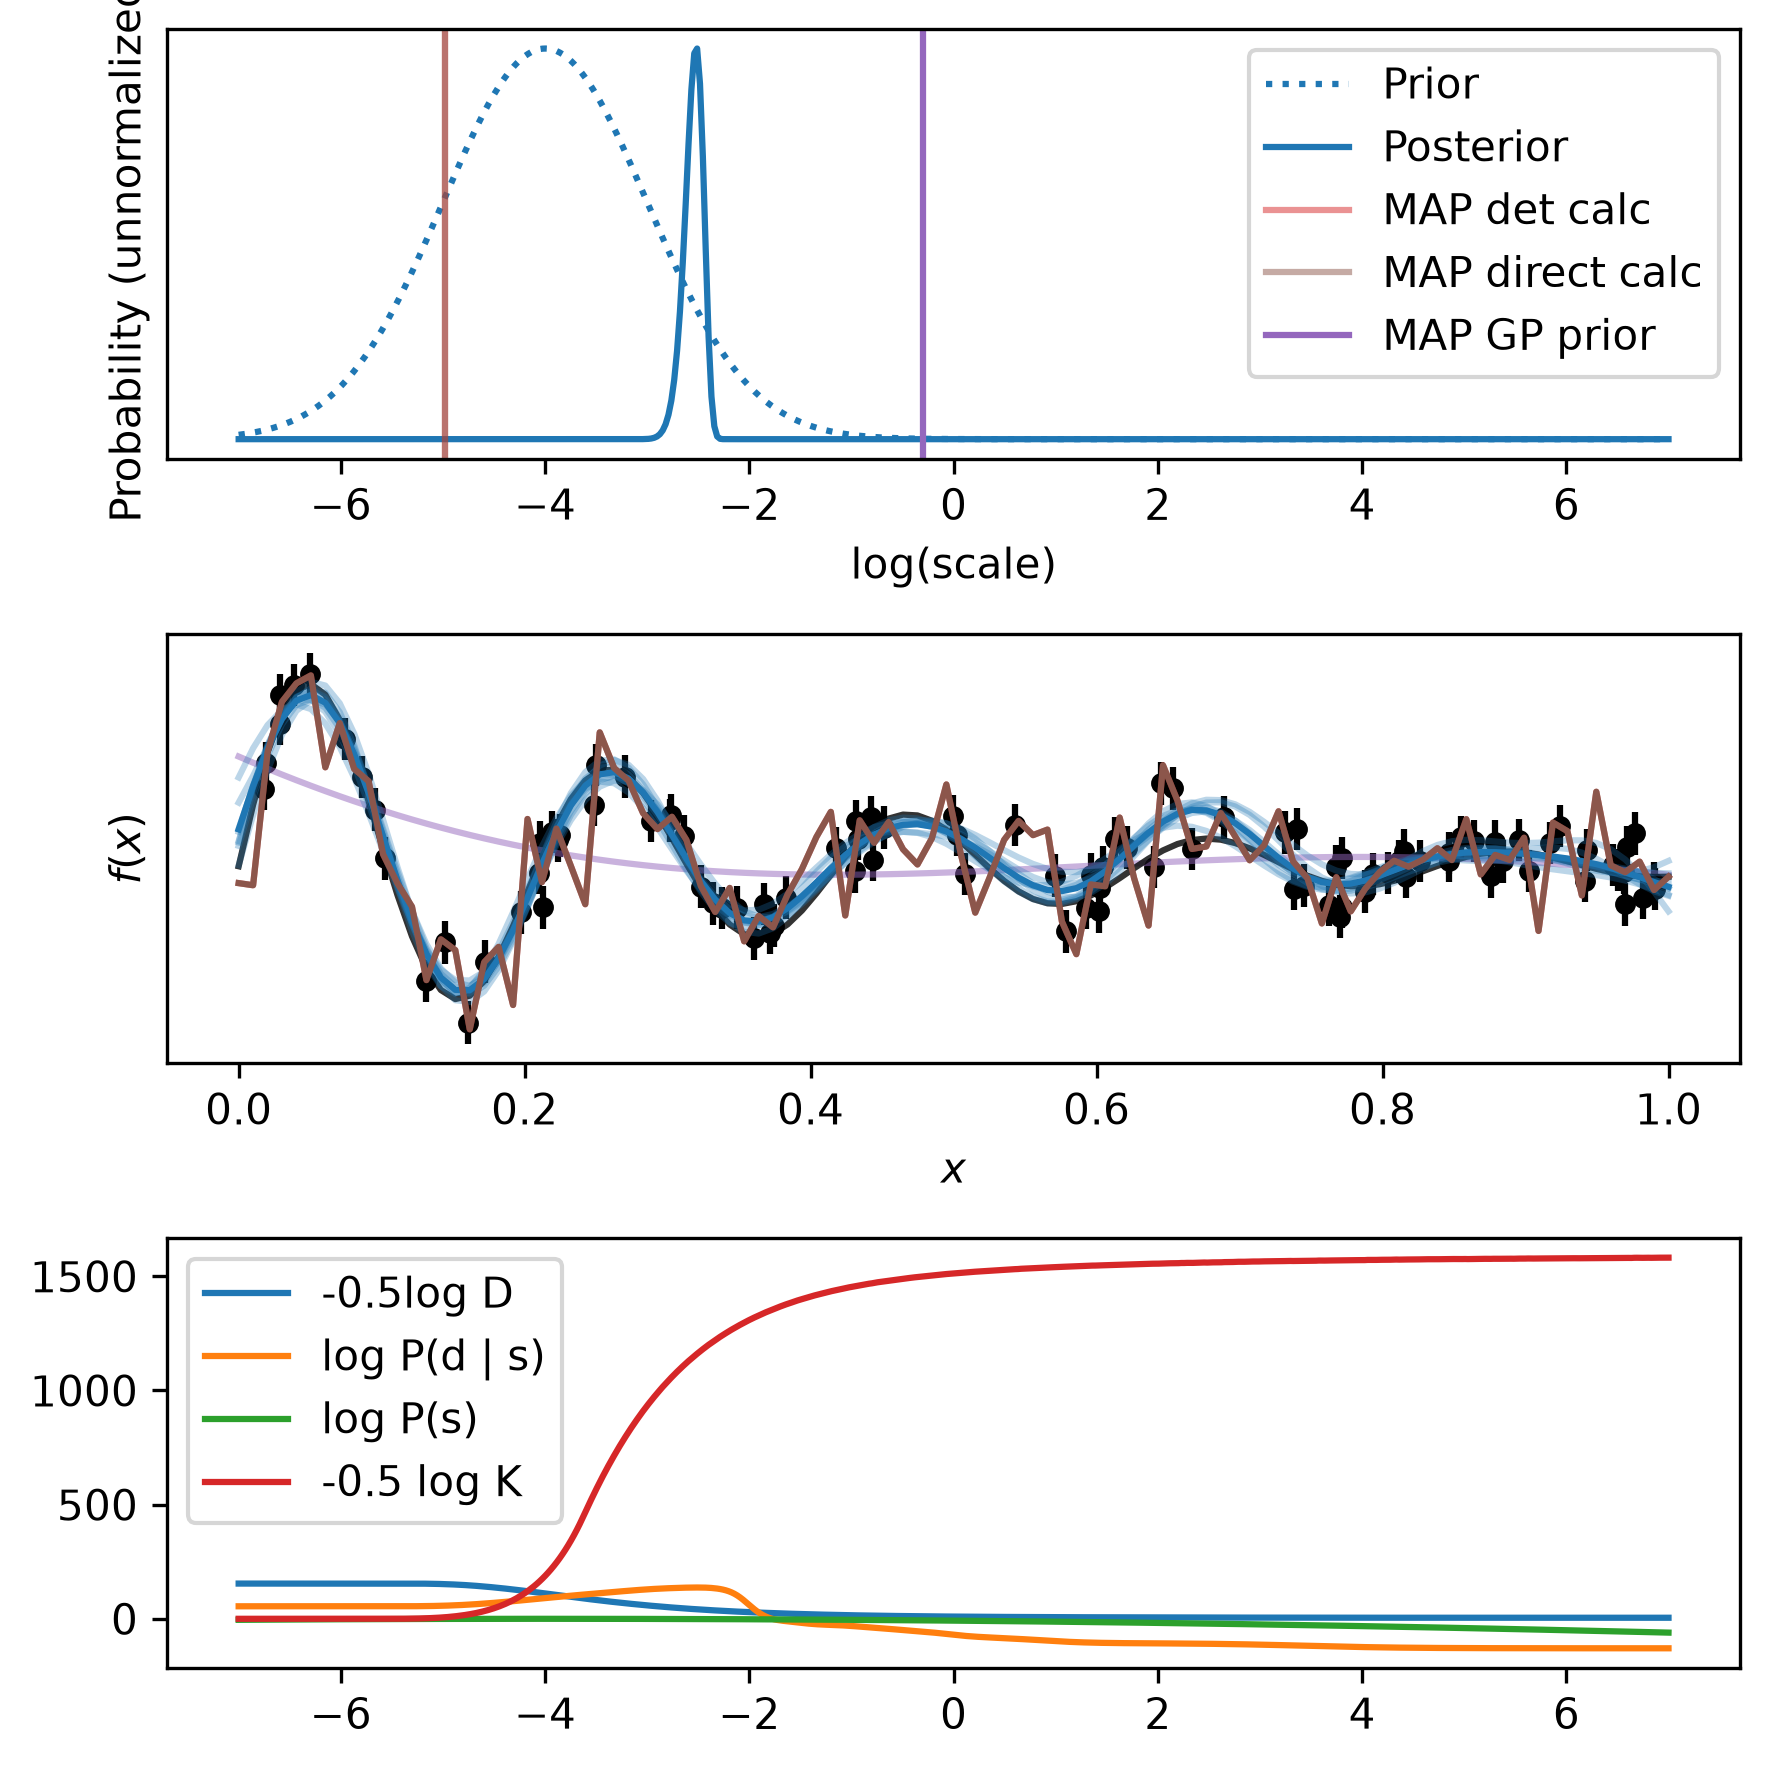

In [8]:
# Set up problem
logscale_grid = jnp.linspace(-7, 7, 500)
logscale_prior = (-4, 1)

def response(logscale, xi):
    f = field(logscale, xi)
    return jnp.interp(data_x, x, f)

def logprior(logscale):
    return -0.5 * ((logscale - logscale_prior[0])/logscale_prior[1])**2

# This is likelihood of observing data_y given that the logscale is some fixed value. The critical step is that data_y are distributed according to the sum of two Gaussians
#: one for the initial GP and one for the added noise. So, given the scale of the GP, because the sum of two Gaussians is still a Gaussian, data_y are still distributed
# according to a Gaussian distribution with covariance S. RR_T is the covariance of the "true" values of the GP at the data points we selected and jnp.diag(data_err**2) 
# is the covariance of the added noise to them.
def loglike(logscale):
    # If we let R' be the reponse matrix that "projects" field values onto the x values we are taking data at, R = R'L (where LL.T = K). This can be proved by the chain rule. Let 
    # g(x) = Lx and let f(x) be the projection. R here is D(f(g(x))) = Df(g(x))Dg(x) = R'L. 
    R = jax.jacobian(lambda xi: response(logscale, xi))(jnp.zeros_like(x))
    S = R @ R.T + jnp.diag(data_err**2)
    _, logdet = jnp.linalg.slogdet(S)
    return -0.5 * (data_y.T @ jnp.linalg.solve(S, data_y) + logdet)

# Scale marginal posterior
prior = jnp.exp(jax.vmap(logprior)(logscale_grid))
posterior = jnp.exp(jax.vmap(loglike)(logscale_grid)) * prior

# Posterior samples
# This uses the formulas I used earlier: D^(-1) = K^(-1) + R^TN^(-1)R and M = DR^TN^(-1)y_obs. However, there is one change: R is the response matrix sending unit normal 
# "noise" (determining how the true baseline GP) is constructed to GP values at the x values where the data is taken. When I did it, R took actual values of the GP to 
# GP values at the x values where the data is taken. So, in this version, K is just unit normal implying the formula for D_inv.
# See question #5 on the dylan_gp notebook; we are effectively parametrizing the white noise. 
def draw_sample(logscale, noise):
    R = jax.jacobian(lambda xi: response(logscale, xi))(jnp.zeros_like(x))
    D_inv = jnp.eye(len(x)) + (R.T / data_err**2) @ R
    m = jnp.linalg.solve(D_inv, R.T @ (data_y / data_err**2))
    L = jnp.linalg.cholesky(D_inv)
    # m + (L_T)^(-1) @ noise are the "noise" values that will generate our GP process BEFORE we apply the covariance kernel to it. See above comment.
    return field(logscale, m + jnp.linalg.solve(L.T, noise))

n_samples = 8
rng, k1, k2 = jr.split(rng, 3)
# Step 1 is to determine a random logscale; we do that here
logscale_samples = jr.choice(k1, logscale_grid, p=posterior, shape=(n_samples,))
# Step 2 is to sample from the posterior distribution CONDITIONAL on the logscale that we chose above
noise = jr.normal(k2, (n_samples, len(x)))
samples = jax.vmap(draw_sample)(logscale_samples,noise)

# Maximum a posteriori
# Given a logscale, we compute the posterior mean and covariance as before. 
def max_logprob(logscale):
    R = jax.jacobian(lambda xi: response(logscale, xi))(jnp.zeros_like(x))
    D_inv = jnp.eye(len(x)) + (R.T / data_err**2) @ R
    D = jnp.linalg.inv(D_inv)
    m = jnp.linalg.solve(D_inv, R.T @ (data_y / data_err**2))
    # Given the logscale, the maximum posterior sample is EXACTLY the mean. Logprob is then -0.5(data_y - Rm).T N^(-1) (data_y - Rm) - 0.5m.Tm It is the analouge of the
    # function below
    #def negative_logdensity(x):
    #    negative_log_p_d_given_s = 0.5*(y_obs - R @ x).T @ inv_cov_data_matrix @ (y_obs - R @ x) 
    #    negative_log_p_s = 0.5*x.T @ inv_cov_prior_matrix @ x
    #    return negative_log_p_d_given_s + negative_log_p_s
    logprob_direct = -0.5 * jnp.sum(((data_y - R @ m) / data_err)**2) - 0.5 * jnp.sum(m**2) + logprior(logscale) 
    K = kernel(logscale)
    _, logdet = jnp.linalg.slogdet(D)
    _, logdetK = jnp.linalg.slogdet(K)
    loglikelyhood = loglike(logscale)
    logprior1 = logprior(logscale)
    logprob = -0.5*logdet + loglikelyhood + logprior1
    logprob_with_GP_as_prior = logprob - 0.5*logdetK
    return logprob, logprob_with_GP_as_prior, logprob_direct, field(logscale, m), logdet, loglikelyhood, logprior1, logdetK

logprobs, logprobs_GP_prior, logprobs_direct, fields, logdets, loglikes, logpriors, logdetsK = jax.vmap(max_logprob)(logscale_grid)
map_logscale = logscale_grid[jnp.argmax(logprobs)]
map_field = fields[jnp.argmax(logprobs)]
map_logscale_direct = logscale_grid[jnp.argmax(logprobs_direct)]
map_field_direct = fields[jnp.argmax(logprobs_direct)]
map_logscale_GP_prior = logscale_grid[jnp.argmax(logprobs_GP_prior)]
map_field_GP_prior = fields[jnp.argmax(logprobs_GP_prior)]

# Plot!
fig, axes = plt.subplots(nrows=3, figsize=(6, 6), dpi=300)
axes[0].plot(logscale_grid, prior / jnp.max(prior), c='C0', ls=':', label='Prior')
axes[0].plot(logscale_grid, posterior / jnp.max(posterior), c='C0', label='Posterior')
axes[0].axvline(map_logscale, color='C3', label='MAP det calc', alpha = 0.5)
axes[0].axvline(map_logscale_direct, color='C5', label='MAP direct calc', alpha = 0.5)
axes[0].axvline(map_logscale_GP_prior, color='C4', label='MAP GP prior')
axes[0].set(yticks=[], xlabel='log(scale)', ylabel='Probability (unnormalized)')
axes[0].legend()
axes[1].plot(x, y, c='k', alpha=0.8)
axes[1].plot(x, jnp.mean(samples, axis=0), c='C0')
axes[1].plot(x, samples.T, c='C0', alpha=0.3)
axes[1].plot(x, map_field, c='C3', zorder=0, alpha = 0.5)
axes[1].plot(x, map_field_GP_prior, c='C4', zorder=1, alpha = 0.5)
axes[1].plot(x, map_field_direct, c='C5', zorder=2)
axes[1].errorbar(data_x, data_y, yerr=data_err, fmt='o', c='k', ms=4, zorder=-1)
axes[1].set(xlabel='$x$', ylabel='$f(x)$', yticks=[])
axes[2].plot(logscale_grid, -0.5*logdets, label = "-0.5log D")
axes[2].plot(logscale_grid, loglikes, label = "log P(d | s)")
axes[2].plot(logscale_grid, logpriors, label = "log P(s)")
axes[2].plot(logscale_grid, -0.5*logdetsK, label = "-0.5 log K")
axes[2].legend()
fig.tight_layout()
plt.show()

As before, the MAP overfits the noise with a rough function which is carefully tuned to match the data. On the other hand, posterior samples come from the smooth region of parameter space which fits less well but has a much larger volume of acceptable configurations. The difference between the two is so large because volume becomes more important as dimensionality increases. If one wants a principled way to learn both a function and its degree of smoothness, accounting for volume is mandatory.

There are a million more things to say here. Is this effect obvious or profound? Is the assumption of stationarity good or bad? What about the MAP in correlated coordinates with a log determinant term? How does this relate to entropy and statistical mechanics? How can we implement this in practice for large, nonlinear models? What other types of problems require accounting for parameter volume? I won't answer these questions here, but fortunately there are many excellent resources that delve into these topics in more depth. Enjoy!

Further reading:
- [A Conceptual Introduction to Hamiltonian Monte Carlo](https://arxiv.org/abs/1701.02434): a vivid discussion of volume, the "typical set," and why HMC works
- [Information Field Theory](https://wwwmpa.mpa-garching.mpg.de/~ensslin/lectures/materials.html): a wealth of resources on Bayesian inference of fields using Gaussian processes
- [Metric Gaussian Variational Inference](https://arxiv.org/abs/1901.11033): a volume-aware algorithm which scales nearly-linearly to massive problems

Acknowledgement: This notebook was created by Benjamin Dodge and is available online [here](https://dodgebc.github.io/extras/smoothing).

My intuition: If we decrease the scale, we can basically fit the data perfectly. However, the volume in 50d space of samples that do so is super small. Some intution for this is as follows: even though there are "more" GPs that fit the data well with a smaller scale , there are also WAY more GPs that fail to fit the data well with a smaller scale. Given that total volume of all GPs with a given scale is 1, the overall volume of GPs that fit the data well with a smaller scale is smaller. 

If we go outside this volume, we very quickly will get a huge penalty on the posterior probability due to being very far away from one of the data points. With a larger scale, we cannot fit the data as well, but the volume of space where we get a decent fit on the data is much higher. As volume in high dimensions scales enormously, we end up with a typical set around a scale substantially larger than the scale containing the mode. 

Another way to rephrase the intuition: consider the formula in the loglike function: 

$$-0.5y_d^TS^{-1}y_d + \log(\det(S))$$

When the scale is small, the log determinant term is practically zero. When the scale is larger, because the data is relatively smooth, the "distance" term hardly increases but the log determinant term really blows up. So, the marginal density increases. 

Question: In HMC, since we already computed the marginal scale density, do we just now have the (un-normalized) posterior formula

$$P(s, scale | data) = P(scale)P(data | s, scale) P(s)$$

and then we let $\pi(q) = \pi(scale, s) = P(scale)P(data | s, scale) P(s)$ and do HMC on the (d + 1)-dimensional vector q?

In [7]:
K = kernel(0)
L = jnp.linalg.cholesky(K)

def response2(y_values):
    return jnp.interp(data_x, x, y_values)


print(jax.jacobian(response2)(jnp.zeros_like(x)) @ L)

print(jax.jacobian(lambda xi: response(0, xi))(jnp.zeros_like(x)))

[[6.12816400e-01 6.09489483e-01 4.24249140e-01 ... 1.29068765e-07
  1.48028931e-07 0.00000000e+00]
 [8.34421712e-01 5.03556722e-01 2.11281877e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [7.45060565e-01 5.73804789e-01 3.08359668e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [7.61646646e-01 5.64125468e-01 2.91400062e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [9.94806906e-01 1.01520660e-01 6.60651927e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [9.99580464e-01 2.87296186e-02 3.88094288e-04 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[6.12816400e-01 6.09489483e-01 4.24249140e-01 ... 1.29068765e-07
  1.48028931e-07 0.00000000e+00]
 [8.34421712e-01 5.03556722e-01 2.11281877e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [7.45060565e-01 5.73804789e-01 3.08359668e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [7.61646646e-01 5.64125468e-01 2.91400062e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]